# Notebook 05 — Cohort & RFM Analysis

*Project:* GA4 + GTM Analytics — Google Merchandise Store  
*Analyst:* Philip Ocheri  
*Notebook Purpose:* Perform cohort analysis by acquisition month, build an RFM-style segmentation framework, and identify high-value customer behaviour patterns from the Google Merchandise Store data.

---

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ga_sessions_2017_audited.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['week'] = df['date'].dt.isocalendar().week
df['day_of_week'] = df['date'].dt.day_name()

print(f"Shape: {df.shape}")
df.head()

Shape: (213, 15)


,date,total_sessions,total_transactions,total_revenue,total_visits,total_bounces,month,month_name,week,session_visit_gap,bounce_rate,conversion_rate,is_revenue_outlier,is_zero_conversion,day_of_week
0,2017-01-01,1364,11,993.01,1364,702,1,Jan,52,0,51.466276,0.806452,False,False,Sunday
1,2017-01-02,1620,18,1027.60,1620,774,1,Jan,1,0,47.777778,1.111111,False,False,Monday
2,2017-01-03,2403,32,4574.74,2403,1087,1,Jan,1,0,45.235123,1.331669,False,False,Tuesday
3,2017-01-04,2390,31,4777.14,2390,1045,1,Jan,1,0,43.723849,1.297071,False,False,Wednesday
4,2017-01-05,2193,41,9097.97,2193,1008,1,Jan,1,0,45.964432,1.869585,False,False,Thursday


## 2. Cohort Analysis — Monthly Revenue Retention

In [2]:
# Monthly cohort — revenue and sessions per month
cohort = df.groupby(['month', 'month_name']).agg(
    total_sessions    = ('total_sessions', 'sum'),
    total_transactions= ('total_transactions', 'sum'),
    total_revenue     = ('total_revenue', 'sum'),
    total_bounces     = ('total_bounces', 'sum')
).reset_index()

cohort['conversion_rate']     = (cohort['total_transactions'] / cohort['total_sessions']) * 100
cohort['bounce_rate']         = (cohort['total_bounces'] / cohort['total_sessions']) * 100
cohort['avg_order_value']     = cohort['total_revenue'] / cohort['total_transactions']
cohort['revenue_per_session'] = cohort['total_revenue'] / cohort['total_sessions']

# Month over month retention index (base = January)
base_revenue = cohort.loc[cohort['month'] == 1, 'total_revenue'].values[0]
cohort['revenue_index'] = (cohort['total_revenue'] / base_revenue) * 100

print("=== MONTHLY COHORT ANALYSIS ===")
print(cohort[['month_name','total_sessions','total_revenue',
              'conversion_rate','avg_order_value',
              'revenue_index']].to_string(index=False))

=== MONTHLY COHORT ANALYSIS ===
month_name  total_sessions  total_revenue  conversion_rate  avg_order_value  revenue_index
       Jan           64694      106248.15         1.102111       149.015638     100.000000
       Feb           62192      116111.60         1.178608       158.406003     109.283409
       Mar           69931      150224.70         1.419971       151.283686     141.390415
       Apr           67126      222767.98         1.428657       232.291950     209.667632
       May           65371      135952.00         1.774487       117.200000     127.957051
       Jun           63578      127992.84         1.527258       131.815489     120.465947
       Jul           71812      160739.86         1.492787       149.943899     151.287208
       Aug            2556        8890.00         1.760563       197.555556       8.367205


## 3. Cohort Revenue Index Chart

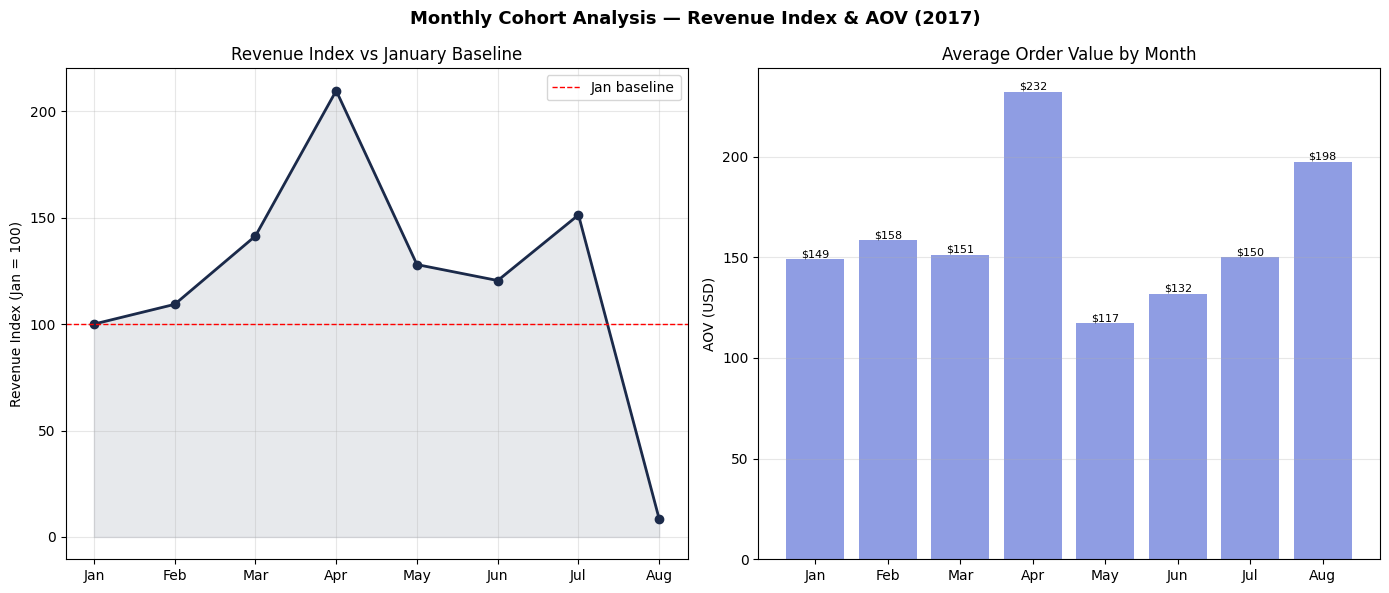

Chart saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Monthly Cohort Analysis — Revenue Index & AOV (2017)',
             fontsize=13, fontweight='bold')

# Revenue index
axes[0].plot(cohort['month_name'], cohort['revenue_index'],
             color='#1B2A4A', marker='o', linewidth=2)
axes[0].fill_between(range(len(cohort)), cohort['revenue_index'],
                     alpha=0.1, color='#1B2A4A')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=1, label='Jan baseline')
axes[0].set_title('Revenue Index vs January Baseline')
axes[0].set_ylabel('Revenue Index (Jan = 100)')
axes[0].set_xticks(range(len(cohort)))
axes[0].set_xticklabels(cohort['month_name'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AOV by month
axes[1].bar(cohort['month_name'], cohort['avg_order_value'],
            color='#7B8CDE', alpha=0.85)
axes[1].set_title('Average Order Value by Month')
axes[1].set_ylabel('AOV (USD)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cohort['avg_order_value']):
    axes[1].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/05_cohort_revenue_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 4. RFM Segmentation Framework

In [4]:
# RFM proxy using daily data
# Recency = days since last revenue recorded
# Frequency = number of transaction days per month
# Monetary = total revenue per month

rfm = df.groupby('month').agg(
    recency   = ('date', 'max'),
    frequency = ('total_transactions', 'sum'),
    monetary  = ('total_revenue', 'sum'),
    sessions  = ('total_sessions', 'sum')
).reset_index()

# Recency score — days from end of period (Aug 1 2017)
end_date = pd.Timestamp('2017-08-01')
rfm['recency_days'] = (end_date - rfm['recency']).dt.days

# RFM scores (1-3 scale)
rfm['R_score'] = pd.qcut(rfm['recency_days'], q=3, labels=[3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=3, labels=[1,2,3])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug'}
rfm['month_name'] = rfm['month'].map(month_names)

print("=== RFM SEGMENTATION BY MONTH ===")
print(rfm[['month_name','recency_days','frequency',
           'monetary','R_score','F_score',
           'M_score','RFM_score']].to_string(index=False))

=== RFM SEGMENTATION BY MONTH ===
month_name  recency_days  frequency  monetary R_score F_score M_score RFM_score
       Jan           182        713 106248.15       1       1       1       111
       Feb           154        733 116111.60       1       1       1       111
       Mar           123        993 150224.70       1       3       3       133
       Apr            93        959 222767.98       2       2       3       223
       May            62       1160 135952.00       2       3       2       232
       Jun            32        971 127992.84       3       2       2       322
       Jul             1       1072 160739.86       3       3       3       333
       Aug             0         45   8890.00       3       1       1       311


## 5. RFM Monetary vs Frequency Chart

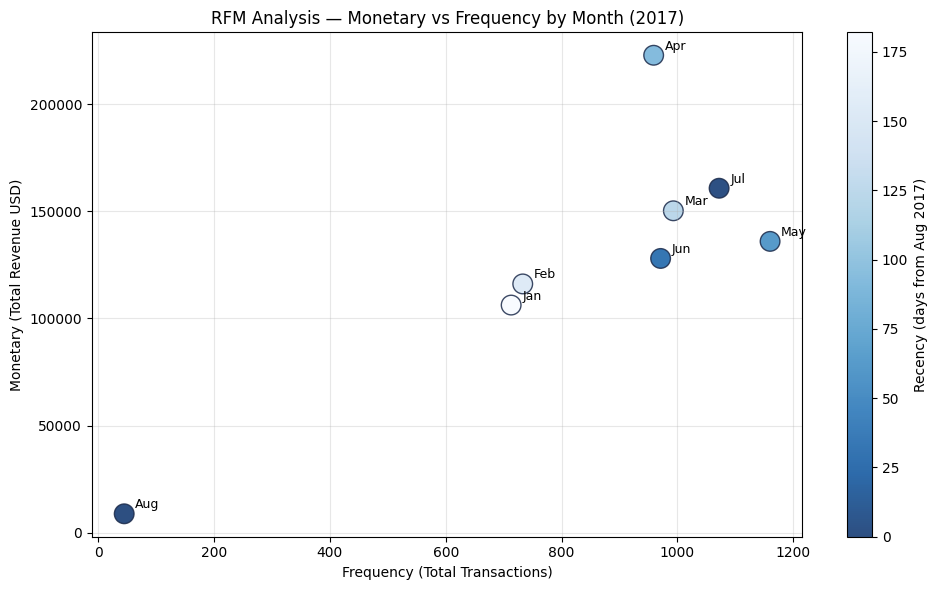

Chart saved.


In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm['frequency'],
    rfm['monetary'],
    c=rfm['recency_days'],
    cmap='Blues_r',
    s=200,
    alpha=0.85,
    edgecolors='#1B2A4A',
    linewidths=1
)
plt.colorbar(scatter, label='Recency (days from Aug 2017)')

for i, row in rfm.iterrows():
    plt.annotate(row['month_name'],
                 (row['frequency'], row['monetary']),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9)

plt.title('RFM Analysis — Monetary vs Frequency by Month (2017)')
plt.xlabel('Frequency (Total Transactions)')
plt.ylabel('Monetary (Total Revenue USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 6. Day of Week Performance

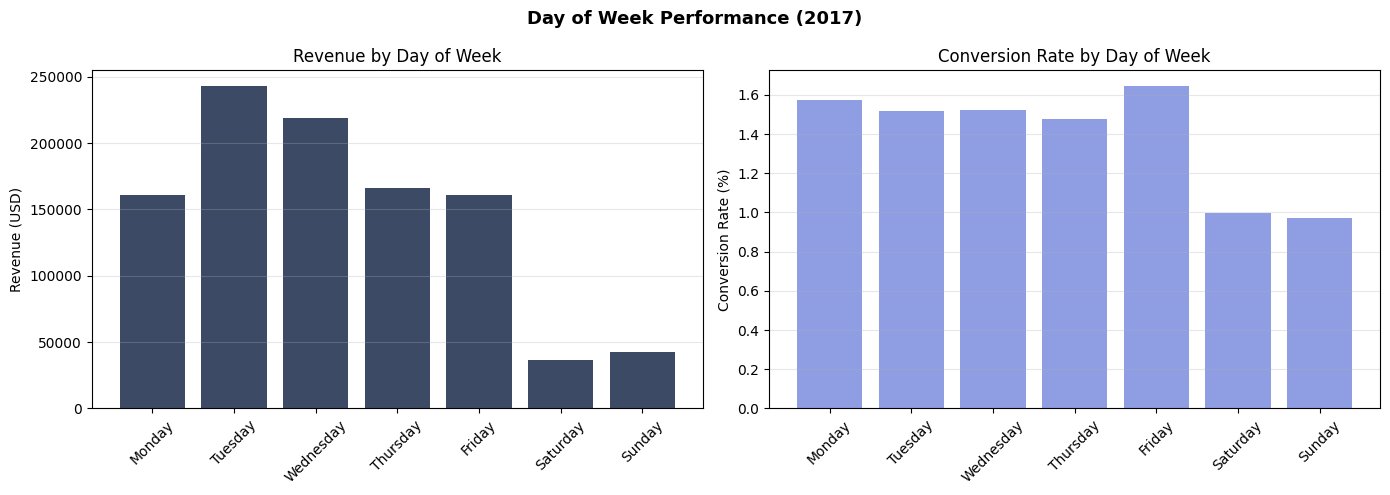

Chart saved.


In [10]:
# Day of week analysis
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df.groupby('day_of_week').agg(
    total_sessions    = ('total_sessions', 'sum'),
    total_transactions= ('total_transactions', 'sum'),
    total_revenue     = ('total_revenue', 'sum')
).reindex(dow_order).reset_index()

dow['conversion_rate'] = (dow['total_transactions'] / dow['total_sessions']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Day of Week Performance (2017)', fontsize=13, fontweight='bold')

axes[0].bar(dow['day_of_week'], dow['total_revenue'],
            color='#1B2A4A', alpha=0.85)
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(dow['day_of_week'], dow['conversion_rate'],
            color='#7B8CDE', alpha=0.85)
axes[1].set_title('Conversion Rate by Day of Week')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/05_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. Export Cohort & RFM Data for Power BI

In [11]:
cohort.to_csv('../data/exports/cohort_monthly.csv', index=False)
rfm.to_csv('../data/exports/rfm_monthly.csv', index=False)
dow.to_csv('../data/exports/day_of_week_performance.csv', index=False)

print("=== COHORT & RFM EXPORTS COMPLETE ===")
print("cohort_monthly.csv          → data/exports/")
print("rfm_monthly.csv             → data/exports/")
print("day_of_week_performance.csv → data/exports/")
print(f"\nCohort rows:  {len(cohort)}")
print(f"RFM rows:     {len(rfm)}")
print(f"DOW rows:     {len(dow)}")

=== COHORT & RFM EXPORTS COMPLETE ===
cohort_monthly.csv          → data/exports/
rfm_monthly.csv             → data/exports/
day_of_week_performance.csv → data/exports/

Cohort rows:  8
RFM rows:     8
DOW rows:     7
